In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x253E8E4B3D0>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class LateralInhibitionNoise(nn.Module):
    def __init__(self, sigma=0.05):
        super().__init__()
        self.sigma = sigma

        kernel = torch.tensor(
            [[0, -1, 0],
             [-1, 4, -1],
             [0, -1, 0]],
            dtype=torch.float32
        )

        self.register_buffer(
            "kernel",
            kernel.unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x

        white_noise = torch.randn_like(x)

        kernel = self.kernel.repeat(x.shape[1], 1, 1, 1)

        correlated_noise = F.conv2d(
            white_noise,
            kernel,
            padding=1,
            groups=x.shape[1]
        )

        noise_std = correlated_noise.std() + 1e-8
        normalized_noise = correlated_noise / noise_std

        return x + self.sigma * normalized_noise

In [13]:
class ContrastAdaptiveNoise(nn.Module):
    def __init__(self, sigma_prop=0.05, sigma_add=0.01):
        super().__init__()
        self.sigma_prop = sigma_prop
        self.sigma_add = sigma_add

    def forward(self, x):
        if not self.training:
            return x

        signal_magnitude = torch.abs(x) + 1e-6

        variance = (self.sigma_prop * signal_magnitude) ** 2 + self.sigma_add ** 2
        std_dev = torch.sqrt(variance)

        noise = torch.randn_like(x) * std_dev

        return x + noise

In [14]:
class MagnoParvoLinearNoise(nn.Module):
    def __init__(
        self,
        num_features,
        ratio_m=0.1,
        sigma_m=0.1,
        ff_m=1.5,
        sigma_p=0.05,
        ff_p=1.1
    ):
        super().__init__()

        self.c_m = int(num_features * ratio_m)
        self.sigma_m = sigma_m * np.sqrt(ff_m)
        self.sigma_p = sigma_p * np.sqrt(ff_p)

    def forward(self, x):
        if not self.training:
            return x

        b, c = x.shape
        device = x.device

        if self.c_m == 0 or self.c_m >= c:
            return x + torch.randn_like(x) * self.sigma_p

        noise_m = torch.randn(
            b, self.c_m, device=device
        ) * self.sigma_m

        noise_p = torch.randn(
            b, c - self.c_m, device=device
        ) * self.sigma_p

        noise = torch.cat([noise_m, noise_p], dim=1)

        return x + noise

In [15]:
class Net(nn.Module):
    def __init__(
        self,
        sigma=0.0,   # LateralInhibitionNoise для block1
        sigma_prop=0.0,   # ContrastAdaptiveNoise для block2
        sigma_m=0.0,   # MagnoParvoNoise для classifier
        sigma_add=0.01,
        ratio_m=0.1
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            LateralInhibitionNoise(sigma=sigma),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            LateralInhibitionNoise(sigma=sigma),

            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ContrastAdaptiveNoise(
                sigma_prop=sigma_prop,
                sigma_add=sigma_add
            ),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ContrastAdaptiveNoise(
                sigma_prop=sigma_prop,
                sigma_add=sigma_add
            ),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 8 * 64, 256),
            nn.ReLU(),
            MagnoParvoLinearNoise(
                num_features=256,
                ratio_m=ratio_m,
                sigma_m=sigma_m,
                sigma_p=sigma_m / 2
            ),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Шум параметров

In [16]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Атаки

In [17]:
def fgsm_attack(model, inputs, labels, criterion, epsilon):
    model.eval()
    inputs.requires_grad = True
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = inputs.grad.data
    adversarial_inputs = inputs + epsilon * data_grad.sign()

    adversarial_inputs = torch.clamp(adversarial_inputs, 0, 1)

    return adversarial_inputs

In [18]:
def pgd_attack(model, inputs, labels, criterion, epsilon, alpha=0.01, num_iter=10):
    adversarial_inputs = inputs.clone().detach().to(device)
    adversarial_inputs.requires_grad = True

    for i in range(num_iter):
        outputs = model(adversarial_inputs)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            adversarial_inputs = adversarial_inputs + alpha * adversarial_inputs.grad.sign()
            perturbation = torch.clamp(adversarial_inputs - inputs, min=-epsilon, max=epsilon)
            adversarial_inputs = torch.clamp(inputs + perturbation, min=0, max=1)
        adversarial_inputs.requires_grad = True

    return adversarial_inputs

In [19]:
def test_with_attack(model, test_loader, criterion, attack, epsilon):
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data[0].to(device), data[1].to(device)

        adversarial_inputs = attack(model, inputs, labels, criterion, epsilon)

        outputs = model(adversarial_inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

# Обучение

In [20]:
num_epochs = 20
lr = 1e-2

In [21]:
criterion = nn.CrossEntropyLoss()

In [22]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [23]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.5022610203242042, val_acc: 0.6168999671936035, val_loss: 1.0920150385627263
epoch: 2, train loss: 1.0504308617503995, val_acc: 0.6884999871253967, val_loss: 0.8715563823905172
epoch: 3, train loss: 0.8749728820412417, val_acc: 0.7224999666213989, val_loss: 0.8016866664343243
epoch: 4, train loss: 0.7858345060491897, val_acc: 0.7432999610900879, val_loss: 0.7298760515979573
epoch: 5, train loss: 0.7160977064152215, val_acc: 0.7845999598503113, val_loss: 0.6366083157967918
epoch: 6, train loss: 0.6684935937039149, val_acc: 0.7827999591827393, val_loss: 0.6475185910357705
epoch: 7, train loss: 0.6333563746604413, val_acc: 0.7958999872207642, val_loss: 0.5938671883902972
epoch: 8, train loss: 0.6032436909827374, val_acc: 0.7971999645233154, val_loss: 0.612645413302168
epoch: 9, train loss: 0.5767798106771818, val_acc: 0.8114999532699585, val_loss: 0.5584454702425606
epoch: 10, train loss: 0.5512278391356965, val_acc: 0.8166999816894531, val_loss: 0.5506275190582758


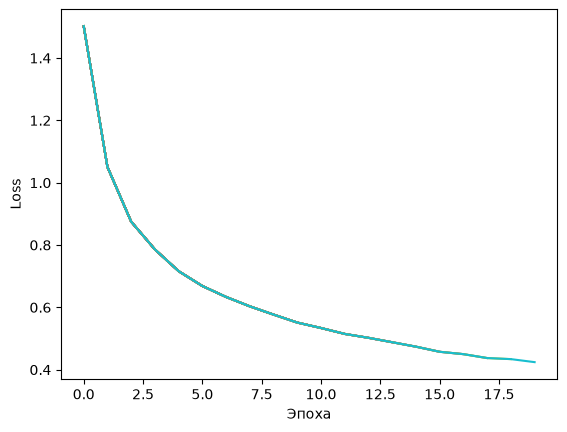

In [24]:
# Baseline: без новых шумов
start = time.time()

net = Net(sigma=0, sigma_prop=0, sigma_m=0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [25]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1827

In [26]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0065

epoch: 1, train loss: 1.5429182052230956, val_acc: 0.5748999714851379, val_loss: 1.1606994723971886
epoch: 2, train loss: 1.070321449448646, val_acc: 0.6771999597549438, val_loss: 0.9035538902765587
epoch: 3, train loss: 0.8903825915897038, val_acc: 0.7261999845504761, val_loss: 0.7961023895046379
epoch: 4, train loss: 0.7940028454352859, val_acc: 0.7610999941825867, val_loss: 0.7065279363076898
epoch: 5, train loss: 0.7345361416719697, val_acc: 0.7734999656677246, val_loss: 0.6575213527377648
epoch: 6, train loss: 0.6840619296693528, val_acc: 0.776199996471405, val_loss: 0.67193688961524
epoch: 7, train loss: 0.6460602920900456, val_acc: 0.7972999811172485, val_loss: 0.5910391132288342
epoch: 8, train loss: 0.6116350673363137, val_acc: 0.7967999577522278, val_loss: 0.6030797562267207
epoch: 9, train loss: 0.5806829801695665, val_acc: 0.8007000088691711, val_loss: 0.5925060823748384
epoch: 10, train loss: 0.5595464342615197, val_acc: 0.8032000064849854, val_loss: 0.5857869341403623
epo

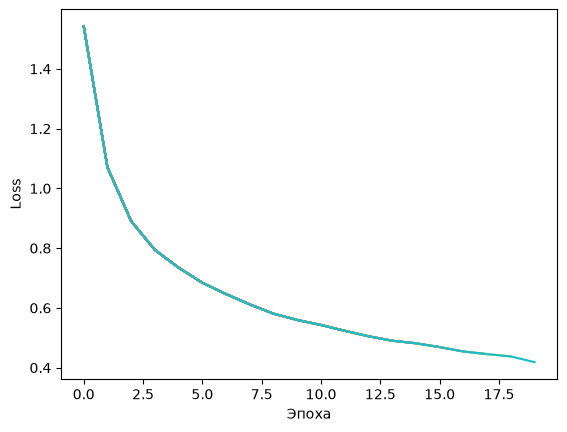

In [27]:
# Только Lateral Inhibition Noise в первом блоке
start = time.time()

net = Net(sigma=0.03, sigma_prop=0, sigma_m=0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [28]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.2052

In [29]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.009

epoch: 1, train loss: 1.5189303530002358, val_acc: 0.5938999652862549, val_loss: 1.1253015693229964
epoch: 2, train loss: 1.0795709113241843, val_acc: 0.6581999659538269, val_loss: 0.987831672535667
epoch: 3, train loss: 0.8910966874579932, val_acc: 0.7173999547958374, val_loss: 0.815713237358045
epoch: 4, train loss: 0.7917933959992971, val_acc: 0.7608000040054321, val_loss: 0.6911249820944629
epoch: 5, train loss: 0.7235846347101057, val_acc: 0.774899959564209, val_loss: 0.6528409689287596
epoch: 6, train loss: 0.6771723784778031, val_acc: 0.7777000069618225, val_loss: 0.6669295460362977
epoch: 7, train loss: 0.6339396260445193, val_acc: 0.7944999933242798, val_loss: 0.5975914324008966
epoch: 8, train loss: 0.6052649794617144, val_acc: 0.796999990940094, val_loss: 0.6019262343267852
epoch: 9, train loss: 0.5760311162670072, val_acc: 0.811199963092804, val_loss: 0.5544192021406149
epoch: 10, train loss: 0.54961755895607, val_acc: 0.8014000058174133, val_loss: 0.5944308072705812
epoch:

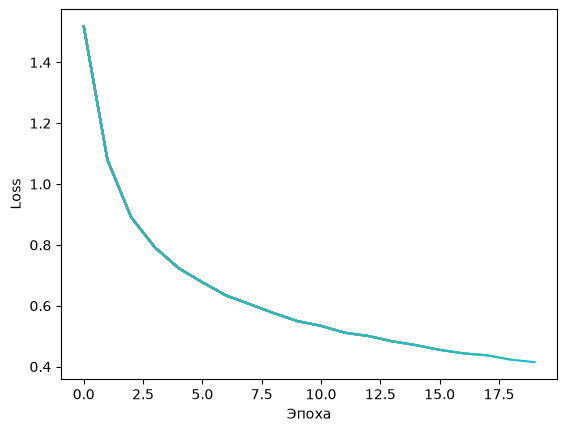

In [30]:
# Только Contrast Adaptive Noise во втором блоке
start = time.time()

net = Net(sigma=0, sigma_prop=0.03, sigma_m=0, sigma_add=0.01)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [31]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.2088

In [32]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0088

epoch: 1, train loss: 1.5388057286435797, val_acc: 0.5824999809265137, val_loss: 1.1681213831599755
epoch: 2, train loss: 1.0663099488385275, val_acc: 0.703499972820282, val_loss: 0.845374185827714
epoch: 3, train loss: 0.877288170907258, val_acc: 0.722599983215332, val_loss: 0.7925009621849542
epoch: 4, train loss: 0.7879547717208215, val_acc: 0.750499963760376, val_loss: 0.7327963468394701
epoch: 5, train loss: 0.7235539607889593, val_acc: 0.7698000073432922, val_loss: 0.6650064655497104
epoch: 6, train loss: 0.6771082069083657, val_acc: 0.7884999513626099, val_loss: 0.6237795873533322
epoch: 7, train loss: 0.6393216662657085, val_acc: 0.7913999557495117, val_loss: 0.6212298326854464
epoch: 8, train loss: 0.6094875518644917, val_acc: 0.7971000075340271, val_loss: 0.5971489065810095
epoch: 9, train loss: 0.5862778344847648, val_acc: 0.8021000027656555, val_loss: 0.5941815357419509
epoch: 10, train loss: 0.5600352453941423, val_acc: 0.8082999587059021, val_loss: 0.5691594275869901
epoc

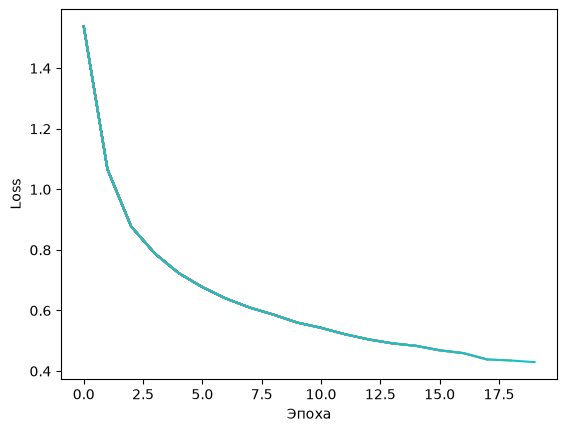

In [33]:
# Только Magno/Parvo Noise в классификаторе
start = time.time()

net = Net(sigma=0, sigma_prop=0, sigma_m=0.03, ratio_m=0.1)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [34]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1704

In [35]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0065

epoch: 1, train loss: 1.5225274082718945, val_acc: 0.6100999712944031, val_loss: 1.1045908550672894
epoch: 2, train loss: 1.0564843013892171, val_acc: 0.6726999878883362, val_loss: 0.9463386965703361
epoch: 3, train loss: 0.8814374225038942, val_acc: 0.7056999802589417, val_loss: 0.8694188451465172
epoch: 4, train loss: 0.7919501364421784, val_acc: 0.7558000087738037, val_loss: 0.7032219752480712
epoch: 5, train loss: 0.7280682960211735, val_acc: 0.7468000054359436, val_loss: 0.7208000444158723
epoch: 6, train loss: 0.6858429419674023, val_acc: 0.7874000072479248, val_loss: 0.6155136465271817
epoch: 7, train loss: 0.6402548418516771, val_acc: 0.7834999561309814, val_loss: 0.6203188013426865
epoch: 8, train loss: 0.6135463122175965, val_acc: 0.8073999881744385, val_loss: 0.5702359921570066
epoch: 9, train loss: 0.5869045247176635, val_acc: 0.8064999580383301, val_loss: 0.572262433888037
epoch: 10, train loss: 0.5628147519462321, val_acc: 0.8158999681472778, val_loss: 0.55015878549105
ep

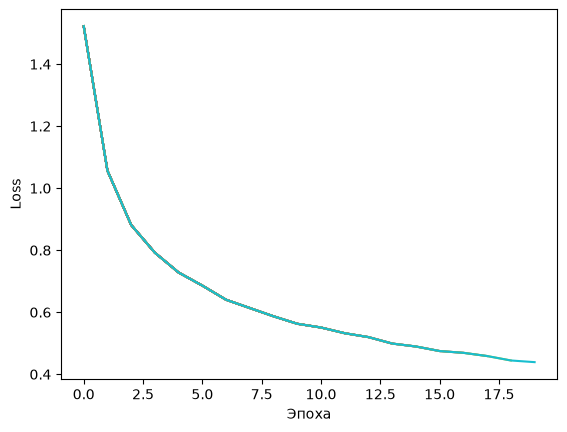

In [36]:
# Все три биологически мотивированных шума
start = time.time()

net = Net(
    sigma=0.03,
    sigma_prop=0.03,
    sigma_m=0.03,
    sigma_add=0.01,
    ratio_m=0.1
)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [37]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1906

In [38]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0094

epoch: 1, train loss: 1.51991950172838, val_acc: 0.6014999747276306, val_loss: 1.115241838406913
epoch: 2, train loss: 1.0619002516766962, val_acc: 0.6553999781608582, val_loss: 1.0148155327084698
epoch: 3, train loss: 0.8760251071273099, val_acc: 0.723800003528595, val_loss: 0.8018115502369555
epoch: 4, train loss: 0.7815983246056147, val_acc: 0.7319999933242798, val_loss: 0.7951353633705573
epoch: 5, train loss: 0.7261787320338833, val_acc: 0.7674999833106995, val_loss: 0.6834137975415097
epoch: 6, train loss: 0.6828529823211547, val_acc: 0.7680999636650085, val_loss: 0.6707678339149379
epoch: 7, train loss: 0.6436857745976152, val_acc: 0.8057000041007996, val_loss: 0.5679223922234548
epoch: 8, train loss: 0.6164879826441532, val_acc: 0.793999969959259, val_loss: 0.6156719421284108
epoch: 9, train loss: 0.5885226541959698, val_acc: 0.8090999722480774, val_loss: 0.5599434172050862
epoch: 10, train loss: 0.5679704160909201, val_acc: 0.8121999502182007, val_loss: 0.5727466725850408
epoc

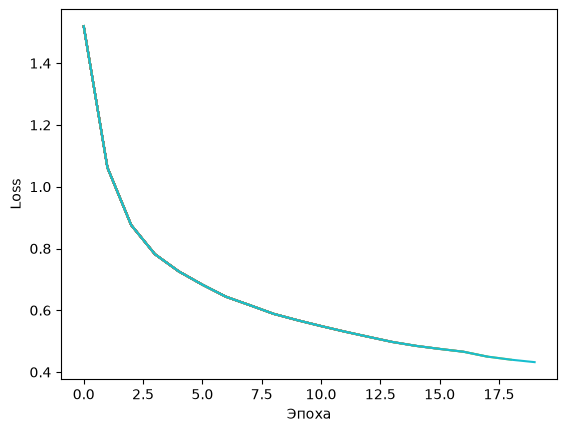

In [39]:
# Более сильный Magno/Parvo шум
start = time.time()

net = Net(
    sigma=0,
    sigma_prop=0,
    sigma_m=0.05,
    ratio_m=0.1
)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [40]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1954

In [41]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0066